# 10-Semantic Segmentation

In Lessons 08 and 09, we taught our network to draw geometric bounding boxes around objects. For many tasks, this is sufficient. But for critical enterprise applications, a bounding box is far too blunt.

If you are building an AI for robotic brain surgery, you cannot simply draw a rectangular box around a tumor—if the scalpel follows a square coordinate system, it will destroy healthy brain tissue. If you are building a self-driving car, a bounding box around a pedestrian includes a massive amount of empty street space.

We must move beyond bounding boxes and transition to **Semantic Segmentation**: the mathematical discipline of classifying *every single pixel* in an image.

Let's set up our PyTorch environment to achieve pixel-perfect precision.

In [1]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torchvision.transforms as transforms
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Semantic Segmentation Environment Ready.")

✅ PyTorch Semantic Segmentation Environment Ready.


# 1. The Mathematics of Pixel Classification

In standard Image Classification (Lesson 04), our network ends with a `nn.Flatten()` layer that mathematically destroys all 2D geometry, resulting in a 1D vector of probabilities: `[Batch, Classes]`.

In Semantic Segmentation, **we never flatten the tensor.** We want the final output to be the exact same spatial height and width as the original input image, but instead of 3 color channels (RGB), the depth of the tensor represents our categories.

* **Input Tensor**: `[Batch, 3, Height, Width]`
* **Output Tensor**: `[Batch, Classes, Height, Width]`

If we have 21 classes (e.g., Background, Road, Car, Cat, Person), our network outputs a tensor with a depth of 21. If we mathematically slice deep into the specific pixel coordinate $(150, 150)$, we will find a vector of 21 numbers. By applying the `argmax()` function across that depth dimension, we assign that exact physical pixel to a specific class.

# 2. Transpose Convolutions (The Decoder)

Standard Convolutions and Pooling layers mathematically compress an image. After 5 pooling blocks, a high-resolution $512 \times 512$ image becomes a dense, abstract $16 \times 16$ feature map.

To achieve segmentation, we need the network to output a $512 \times 512$ mask. How do we mathematically blow a $16 \times 16$ matrix back up? We use a new mathematical operation: the **Transpose Convolution** (often incorrectly called a Deconvolution).

While a standard Convolution takes a $3 \times 3$ grid of pixels and squashes them into a single number, a Transpose Convolution does the exact opposite. It takes a single number, multiplies it by a learnable $3 \times 3$ kernel, and *scatters* the result across a $3 \times 3$ grid.

$$O_{size} = (I_{size} - 1) \times S - 2P + K + O_{padding}$$

By setting the Stride ($S$) to 2, the Transpose Convolution effectively doubles the spatial height and width of the tensor. By stacking these layers, we create a **Decoder** that mathematically unwinds the compression of the Feature Extractor (the Encoder).

# 3. The U-Net Architecture (The Skip Connection)

There is a fatal geometric flaw in a pure Encoder-Decoder pipeline.
When the Encoder compresses the image down to $16 \times 16$, the network learns highly complex, deep concepts (e.g., *"I am looking at a cat"*). However, it has mathematically destroyed the high-resolution location data (e.g., *"Exactly which pixel was the edge of the cat's left ear?"*).
When the Decoder scales the matrix back up, the resulting mask is blurry and blob-like.

In 2015, researchers solved this by inventing **U-Net** (originally designed for Biomedical Image Segmentation).

U-Net introduces a symmetrical "U" shape with **Skip Connections** that physically bridge the Encoder and the Decoder.

1. As the image goes *down* the Encoder, we save a copy of the high-resolution feature maps at every spatial level.
2. As the image goes *up* the Decoder, before we apply the next convolution, we mathematically **concatenate** the saved high-resolution map from the Encoder directly onto the upsampled map of the Decoder.

The Decoder is suddenly infused with the exact, pixel-perfect geometric boundaries that were lost during compression!

# 4. Executing an Enterprise Segmentation Network

While U-Net is the gold standard for medical imaging, for complex natural images, we use massive enterprise architectures like **DeepLabV3**. DeepLab utilizes Dilated (Atrous) Convolutions to expand the receptive field without losing spatial resolution.

Let's load the `skimage.data.cat()` image, pass it through a live DeepLabV3 network, and execute the `argmax` mathematics to extract the precise pixel mask.

--- 📥 Downloading Pretrained DeepLabV3 (ResNet-50) ---


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


Input Tensor Shape: torch.Size([1, 3, 300, 451])
--- 🧠 Executing Pixel-Level Forward Pass ---
Raw Output Tensor Shape: torch.Size([21, 300, 451]) (21 Classes)
Final 2D Segmentation Mask Shape: (300, 451)


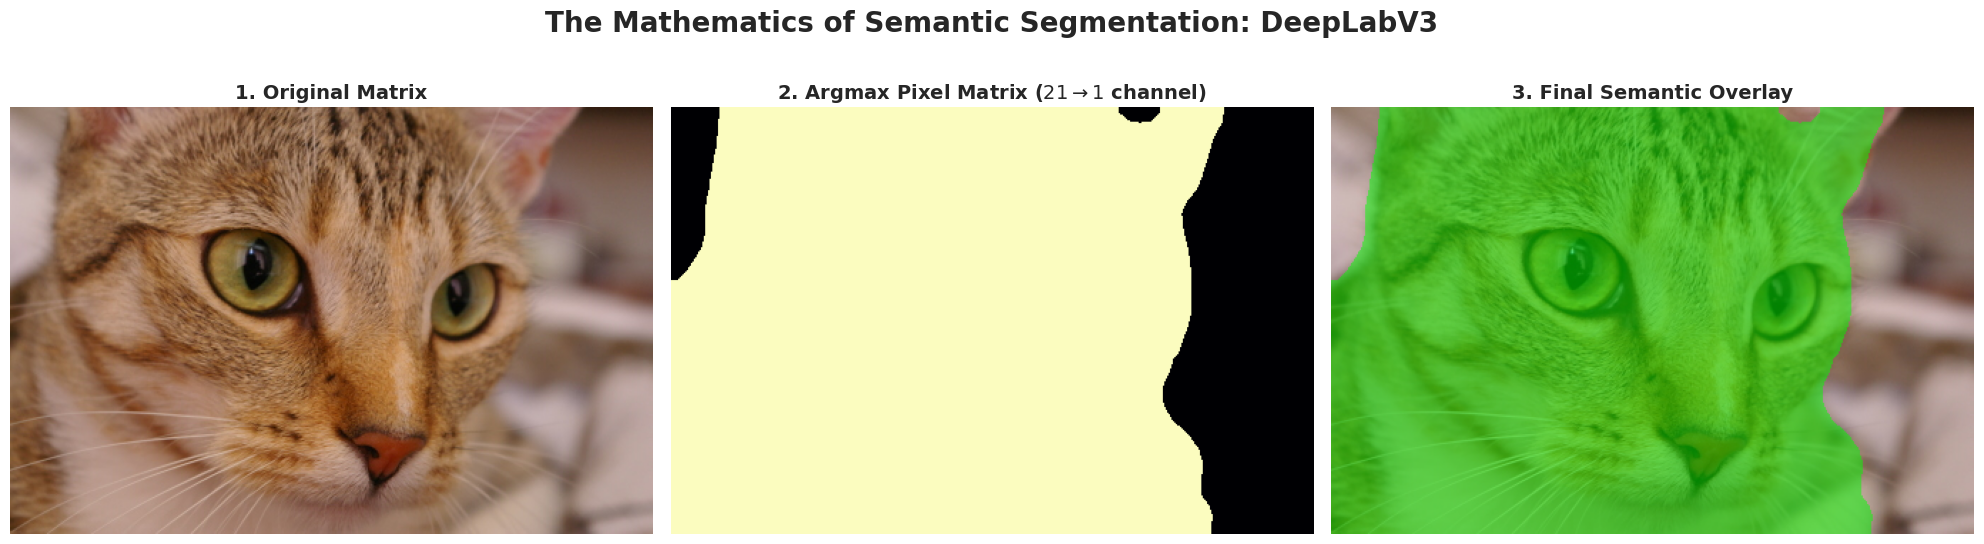

--- 💡 Engineering Insight ---
Look closely at Plot 3. Unlike a bounding box, the network has classified the exact geometric contour of the cat. It successfully ignored the grass and the background structure. It mathematically evaluated all 135,300 pixels individually, projected them into 21-dimensional space, and confidently assigned the label of '8' (Cat) to the specific organic curve of the fur!


In [2]:
# 1. Fetch the Target Image
numpy_cat = data.cat() # High-resolution RGB cat photograph

# 2. Download and Initialize the Pretrained Enterprise Architecture
print("--- 📥 Downloading Pretrained DeepLabV3 (ResNet-50) ---")
# Trained on the Pascal VOC dataset (21 classes, including 'cat' and 'background')
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights, progress=False)
model.eval() # Set to evaluation mode!

# 3. Prepare the Image Tensor
# DeepLab requires standard ImageNet normalization
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = preprocess(numpy_cat).unsqueeze(0)
print(f"Input Tensor Shape: {input_tensor.shape}")

# 4. Execute the Forward Pass
print("--- 🧠 Executing Pixel-Level Forward Pass ---")
with torch.no_grad():
    # DeepLab returns a dictionary. The main output is stored in the 'out' key.
    output = model(input_tensor)['out'][0]

print(f"Raw Output Tensor Shape: {output.shape} (21 Classes)")

# 5. The Mathematics of Pixel Classification
# We have a tensor of [21, 300, 451]. 
# We apply argmax across dimension 0 (the classes) to collapse it into a single 2D map!
predicted_mask = torch.argmax(output, dim=0).numpy()

print(f"Final 2D Segmentation Mask Shape: {predicted_mask.shape}")

# Pascal VOC Class 8 is 'cat'. Let's isolate the mathematical boolean mask for the cat.
CAT_CLASS_ID = 8
boolean_cat_mask = (predicted_mask == CAT_CLASS_ID)

# 6. Visualizing the Mathematical Segmentation
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("The Mathematics of Semantic Segmentation: DeepLabV3", fontsize=20, fontweight='bold')

# Plot A: Original Image
axes[0].imshow(numpy_cat)
axes[0].set_title("1. Original Matrix", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: The Raw Output Mask
# We plot the raw integer map. Background is 0, Cat is 8.
axes[1].imshow(predicted_mask, cmap='magma')
axes[1].set_title("2. Argmax Pixel Matrix ($21 \\rightarrow 1$ channel)", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: The Semantic Overlay
# We create an RGB overlay by applying a green tint specifically to the true pixels in the boolean mask
overlay_image = numpy_cat.copy()
# Create a green tint mask [R=0, G=255, B=0]
green_tint = np.zeros_like(numpy_cat)
green_tint[:, :, 1] = 255 

# Mathematically blend the original image and the green tint ONLY where the mask is True
alpha = 0.5
overlay_image[boolean_cat_mask] = (overlay_image[boolean_cat_mask] * (1 - alpha) + green_tint[boolean_cat_mask] * alpha).astype(np.uint8)

axes[2].imshow(overlay_image)
axes[2].set_title("3. Final Semantic Overlay", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Engineering Insight ---")
print("Look closely at Plot 3. Unlike a bounding box, the network has classified the exact geometric contour of the cat. It successfully ignored the grass and the background structure. It mathematically evaluated all 135,300 pixels individually, projected them into 21-dimensional space, and confidently assigned the label of '8' (Cat) to the specific organic curve of the fur!")

## Real-World Use Case or Analogy:

Think of the U-Net architecture and Semantic Segmentation like **A Lead Detective and a Sketch Artist working together**:

* **The Problem**: A crime scene is a massive, complex city block ($512 \times 512$).
* **The Encoder (The Detective)**: The Detective walks through the scene, constantly summarizing the data to understand the "big picture." They ignore individual pebbles and focus on the major elements. By the end, they have a highly compressed, deep understanding of the crime (e.g., *"The suspect dropped a weapon near the car"*). However, because they only focused on the big picture, they forgot *exactly* how many inches the weapon was from the tire.
* **The Decoder (The Sketch Artist)**: The Sketch Artist tries to redraw the crime scene perfectly based *only* on the Detective's highly compressed summary. Because the spatial details are missing, the resulting drawing is a blurry, vague blob.
* **The Skip Connection (The Crime Scene Photos)**: The genius of U-Net. As the Detective was walking through the scene, a photographer took high-resolution photos at every step (saving the spatial feature maps). Now, when the Sketch Artist is drawing, they don't just rely on the Detective's summary—they look directly at the high-res photos (Concatenation). The Sketch Artist uses the Detective's deep semantic understanding to know *what* is important, and uses the photos to know *exactly where* to draw the pixel-perfect lines!